In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# Load data
df = pd.read_csv("bitcoin_prices_2025.csv")  # Adjust filename as needed
df['open_time'] = pd.to_datetime(df['open_time'])  # Convert dates
df = df.dropna(subset=['close'])  # Handle missing values

# Feature Scaling (only 'close' for simplicity, as features are derived from it)
close_scaler = MinMaxScaler()
df['close'] = close_scaler.fit_transform(df[['close']])

# Feature Engineering
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()
df['Lag_1'] = df['close'].shift(1)
df['Lag_2'] = df['close'].shift(2)
df = df.dropna()  # Drop rows with NaN values from rolling calculations

In [3]:
# Split data into train and test sets (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_df = df[:train_size]
test_df = df[train_size:]

# Prepare training data
X_train = train_df[['close', 'SMA_20', 'SMA_50', 'Lag_1', 'Lag_2']].values
y_train = train_df['close'].values
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

# Prepare testing data
X_test = test_df[['close', 'SMA_20', 'SMA_50', 'Lag_1', 'Lag_2']].values
y_test = test_df['close'].values
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Build and train the LSTM model
model = Sequential()
model.add(Input(shape=(1, 5)))  # 5 features, 1 timestep
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

In [6]:
# Predict on test set
y_pred = model.predict(X_test)

# Inverse transform for interpretable metrics
y_test_inv = close_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = close_scaler.inverse_transform(y_pred)

# Calculate regression metrics
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"MSE: {mse}, RMSE: {rmse}, MAE: {mae}")

# Compute actual price movements (1 = up, 0 = down)
actual_movements = (y_test[1:] > y_test[:-1]).astype(int)

# Compute predicted price movements (1 = up, 0 = down)
predicted_movements = (y_pred[1:, 0] > y_test[:-1]).astype(int)

# Compute and print the confusion matrix
cm = confusion_matrix(actual_movements, predicted_movements)
print("Confusion Matrix:")
print(cm)

# Save evaluation results to a separate file
with open("evaluation_results.txt", "w") as f:
    f.write(f"MSE: {mse}\n")
    f.write(f"RMSE: {rmse}\n")
    f.write(f"MAE: {mae}\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm))

    print("Shape of actual_movements:", actual_movements.shape)
print("Shape of predicted_movements:", predicted_movements.shape)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MSE: 7840514.609557128, RMSE: 2800.091893055856, MAE: 2088.8280856502756
Confusion Matrix:
[[ 99 160]
 [ 86 198]]
Shape of actual_movements: (543,)
Shape of predicted_movements: (543,)


In [7]:
# Prepare for future predictions
last_date = df['open_time'].iloc[-1]
future_dates = [last_date + timedelta(days=i) for i in range(1, 121)]  # Next 4 months (~120 days)
last_data = df[['close', 'SMA_20', 'SMA_50', 'Lag_1', 'Lag_2']].iloc[-1].values.reshape(1, 1, 5)
future_predictions = []

# Predict iteratively
temp_df = df.tail(50).copy()  # Last 50 days for SMA calculations
for _ in range(120):
    pred = model.predict(last_data, verbose=0)[0, 0]
    future_predictions.append(pred)
    
    # Update temp_df with predicted value
    new_row = pd.DataFrame({
        'close': [pred],
        'SMA_20': [temp_df['close'].tail(20).mean()],
        'SMA_50': [temp_df['close'].tail(50).mean()],
        'Lag_1': [temp_df['close'].iloc[-1]],
        'Lag_2': [temp_df['close'].iloc[-2]]
    }, index=[temp_df.index[-1] + 1])
    temp_df = pd.concat([temp_df, new_row]).tail(50)
    last_data = new_row.values.reshape(1, 1, 5)

# Inverse transform predictions
future_predictions = close_scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Save predictions to CSV
predictions_df = pd.DataFrame({'date': future_dates, 'predicted_close': future_predictions.flatten()})
predictions_df.to_csv("bitcoin_price_predictions_2025.csv", index=False)

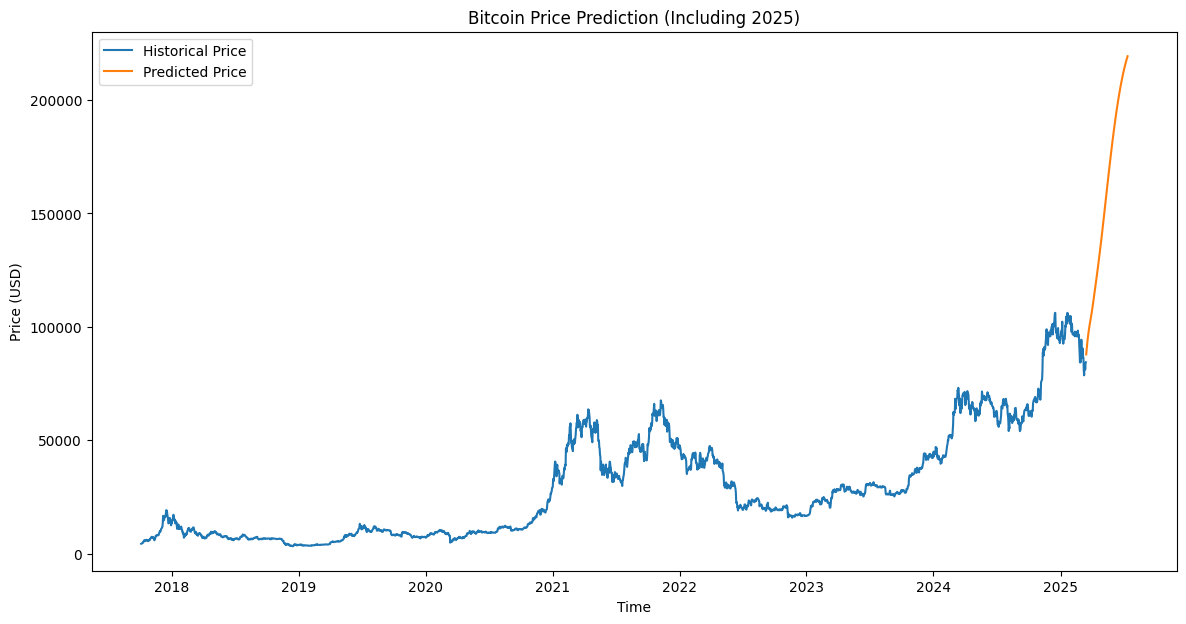

In [8]:
# Inverse transform historical prices
historical_close = close_scaler.inverse_transform(df[['close']])

# Plot historical and predicted prices
plt.figure(figsize=(14, 7))
plt.plot(df['open_time'], historical_close, label='Historical Price')
plt.plot(future_dates, future_predictions, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.title('Bitcoin Price Prediction (Including 2025)')
plt.legend()
plt.show()